In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def tokenize(text: str) -> list[str]:
    """Tokenize text into lowercase word tokens (simple, language-agnostic)."""
    return re.findall(r"\b\w+\b", text.lower())

def mattr_from_tokens(tokens: list[str], window: int = 50) -> float:
    """Compute Moving-Average Type-Token Ratio (MATTR) for a list of tokens.

    If text is shorter than the window, falls back to simple TTR on the full text.
    """
    n = len(tokens)
    if n == 0:
        return np.nan
    if n < window:
        return len(set(tokens)) / n

    ttrs = []
    # Sliding window
    for start in range(0, n - window + 1):
        chunk = tokens[start:start + window]
        ttrs.append(len(set(chunk)) / window)
    return float(np.mean(ttrs))


# CONFIG

folder_path = "stylo_texts"  # pfad noch anpassen
WINDOW = 50
NORM_N = 96

rows = []
for fn in sorted(os.listdir(folder_path)):
    if not fn.endswith(".txt"):
        continue
    full_path = os.path.join(folder_path, fn)
    with open(full_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()

    tokens = tokenize(text)

    rows.append({
        "Text": fn,
        "Tokens_total": len(tokens),
        "MATTR_full": mattr_from_tokens(tokens, window=WINDOW),
        f"MATTR_first_{NORM_N}": mattr_from_tokens(tokens[:min(NORM_N, len(tokens))], window=min(WINDOW, max(1, min(NORM_N, len(tokens))))),
        "Used_tokens_for_norm": min(NORM_N, len(tokens))
    })

df_mattr = pd.DataFrame(rows)
df_mattr = df_mattr.sort_values(f"MATTR_first_{NORM_N}", ascending=False)
df_mattr

,Text,Tokens_total,MATTR_full,MATTR_first_96,Used_tokens_for_norm
4,Text3_1 KI Tieck.txt,128,0.893671,0.904681,96
5,Text3_2 Tieck.txt,96,0.891915,0.891915,96
3,Text2_2 Andersen.txt,443,0.849543,0.877447,96
7,Text4_2 KI Tieck.txt,181,0.847424,0.875745,96
1,Text1_2 KI Andersen.txt,290,0.853942,0.868936,96
6,Text4_1 Tieck.txt,190,0.865674,0.854043,96
0,Text1_1 Andersen.txt,295,0.863171,0.821277,96
2,Text2_1 KI Andersen.txt,327,0.852374,0.817872,96


/tmp/ipython-input-417/3342304205.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


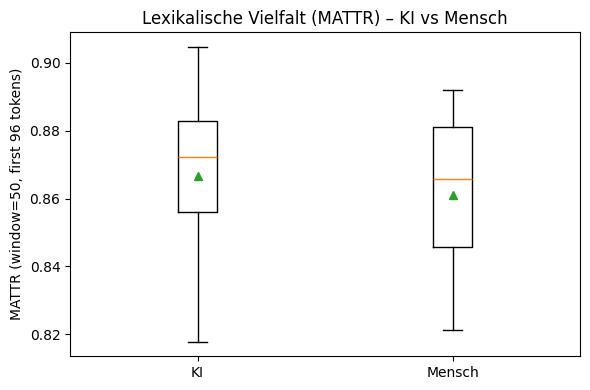

In [ ]:
ki = df_mattr[df_mattr["Text"].str.contains("KI")]
human = df_mattr[~df_mattr["Text"].str.contains("KI")]

plt.figure(figsize=(6,4))
plt.boxplot(
    [ki[f"MATTR_first_{NORM_N}"], human[f"MATTR_first_{NORM_N}"]],
    labels=["KI", "Mensch"],
    showmeans=True
)
plt.ylabel(f"MATTR (window={WINDOW}, first {NORM_N} tokens)")
plt.title("Lexikalische Vielfalt (MATTR) – KI vs Mensch")
plt.tight_layout()
plt.show()

/tmp/ipython-input-417/1423894239.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


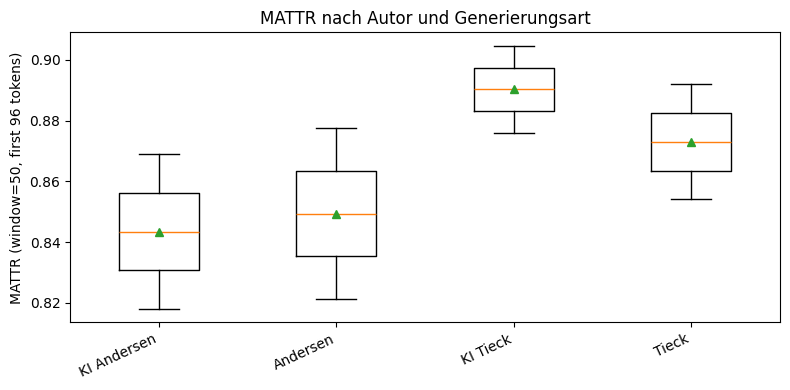

In [ ]:
groups = {
    "KI Andersen": df_mattr[df_mattr["Text"].str.contains("KI") & df_mattr["Text"].str.contains("Andersen")],
    "Andersen": df_mattr[~df_mattr["Text"].str.contains("KI") & df_mattr["Text"].str.contains("Andersen")],
    "KI Tieck": df_mattr[df_mattr["Text"].str.contains("KI") & df_mattr["Text"].str.contains("Tieck")],
    "Tieck": df_mattr[~df_mattr["Text"].str.contains("KI") & df_mattr["Text"].str.contains("Tieck")]
}

plt.figure(figsize=(8,4))
plt.boxplot(
    [groups[k][f"MATTR_first_{NORM_N}"] for k in groups],
    labels=list(groups.keys()),
    showmeans=True
)
plt.ylabel(f"MATTR (window={WINDOW}, first {NORM_N} tokens)")
plt.title("MATTR nach Autor und Generierungsart")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
